In [1]:
import pandas as pd
import re
import json


input_path = "jaemin_20251204_1_.txt"  

with open(input_path, "r", encoding="utf-8") as f:
    text = f.read()

pattern = r"(\/[^\n]+\/(normal|abnormal)\/[^\n]+)\s*[\s\S]*?(?:```json\s*([\s\S]*?)\s*```|(\{[\s\S]*?\}))"
matches = re.findall(pattern, text, re.DOTALL)

rows = []

for match in matches:
    
    path, truth, json_block, json_raw = match
    json_str = json_block if json_block else json_raw
    
    try:
        data = json.loads(json_str)

        is_scam = bool(data.get("is_scam"))

        if (is_scam and truth == "abnormal") or (not is_scam and truth == "normal"):
            result = True
        else:
            result = False

        rows.append({
            "filename": path.split("/")[-1].strip(),
            "truth": truth,
            "is_scam": data.get("is_scam"),
            "result": result,
            "is_correct": data.get("is_scam"),
            "confidence": data.get("confidence"),
            "risk": data.get("risk"),
            "evidence": "; ".join(data.get("evidence", [])),
            "explanation": data.get("explanation"),            
        })
    except json.JSONDecodeError as e:
        print(f"JSON 파싱 오류 발생 ({path}): {e}")

df = pd.DataFrame(rows, columns=["filename", "truth", "is_scam", "result", "confidence", "risk", "evidence", "explanation"])

output_path = "scam_results.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"CSV 파일 생성 완료: {output_path}")
print(df)


CSV 파일 생성 완료: scam_results.csv
    filename     truth  is_scam  result  confidence  risk  \
0   0025.mp4    normal     True   False        0.90  high   
1   0011.mp4    normal    False    True        0.35   low   
2   0024.mp4    normal    False    True        0.75   low   
3   0004.mp4    normal    False    True        0.35   low   
4   0001.mp4    normal    False    True        0.25   low   
5   0006.mp4    normal    False    True        0.35   low   
6   0016.mp4    normal    False    True        0.35   low   
7   0005.mp4    normal    False    True        0.25   low   
8   0018.mp4    normal    False    True        0.35   low   
9   0023.mp4    normal    False    True        0.35   low   
10  0007.mp4    normal    False    True        0.35   low   
11  0014.mp4    normal    False    True        0.65   low   
12  0021.mp4    normal    False    True        0.35   low   
13  0027.mp4    normal    False    True        0.25   low   
14  0012.mp4    normal     True   False        0.92  h

In [2]:
df.groupby(["truth", "result"]).agg({"filename":"count"})

filename
truth    result          
abnormal False          5
         True          22
normal   False          3
         True          25

In [4]:
df[df['result']==True]

,filename,truth,is_scam,result,confidence,risk,evidence,explanation
1,0011.mp4,normal,False,True,0.25,low,할바하게 되면 하는 것; 이어폰 빼고,The video appears to be a humorous or instruct...
2,0024.mp4,normal,False,True,0.25,low,Normal cereal consumption; Product demonstrati...,The video shows a normal product usage scenari...
3,0004.mp4,normal,False,True,0.25,low,Normal job-related content; No explicit reques...,The video appears to be about a part-time job ...
4,0001.mp4,normal,False,True,0.15,low,Normal job-related content; No explicit reques...,The video discusses the challenges of part-tim...
5,0006.mp4,normal,False,True,0.25,low,;,The video does not contain any strong or direc...
6,0016.mp4,normal,False,True,0.25,low,고작한 장난을 한 번,The video appears to be a demonstration of sol...
8,0018.mp4,normal,False,True,0.15,low,한번씩만,The video appears to be a review or recommenda...
9,0023.mp4,normal,False,True,0.15,low,nonstick coating; multi-cookpan,The video describes the features of a nonstick...
10,0007.mp4,normal,False,True,0.15,low,7일간 단기알바 만으로 100만원 벌기,The video appears to be about a person's exper...
11,0014.mp4,normal,False,True,0.35,low,아아 음료만이; 레몬에어드 음료재,The video appears to be a tutorial or demonstr...


In [5]:
df[df['result']==False]

,filename,truth,is_scam,result,confidence,risk,evidence,explanation
0,0025.mp4,normal,True,False,0.90,high,우버 택시 50% 헤택; 그시절택시요금,The video contains strong scam indicators such...
7,0005.mp4,normal,True,False,0.92,high,knife; customer complaint,The video shows a customer repeatedly asking f...
13,0027.mp4,normal,True,False,0.92,high,guaranteed or outsized/rapid profits,The video promises a significant increase in c...
22,0026.mp4,normal,True,False,0.90,high,우버 택시 50% 헤택; 그시절택시요금,The video contains strong scam indicators such...
28,0025.mp4,abnormal,False,False,0.25,low,recommendation code; app usage,The video appears to be a normal informational...
33,0004.mp4,abnormal,False,False,0.15,low,Various sandals displayed on wooden shelves; H...,The video shows various styles of sandals in d...
38,0005.mp4,abnormal,False,False,0.35,low,가상화폐 구매대행 모집; 한 달이면 마음에 드는 차를 살 수 있습니다.,The video describes a cryptocurrency purchase ...
39,0018.mp4,abnormal,False,False,0.35,low,다음message,The content appears to be a normal chat conver...
40,0007.mp4,abnormal,False,False,0.35,low,사람들에게 공과 희망을; 볼어 봐주는 사이비 교수,The video shows a demonstration of self-defens...
42,0031.mp4,abnormal,False,False,0.35,low,;,The description does not contain any strong or...


Precision: [0.49090909 0.55102041 0.76666667 0.84615385 0.88       0.92307692
 1.         1.        ]
Recall: [1.         1.         0.85185185 0.81481481 0.81481481 0.44444444
 0.25925926 0.        ]
AP (mAP): 0.8662


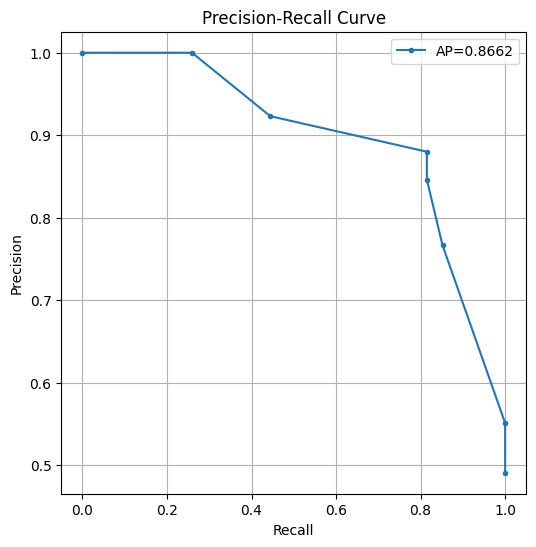

Optimal threshold (F1 max): 0.90


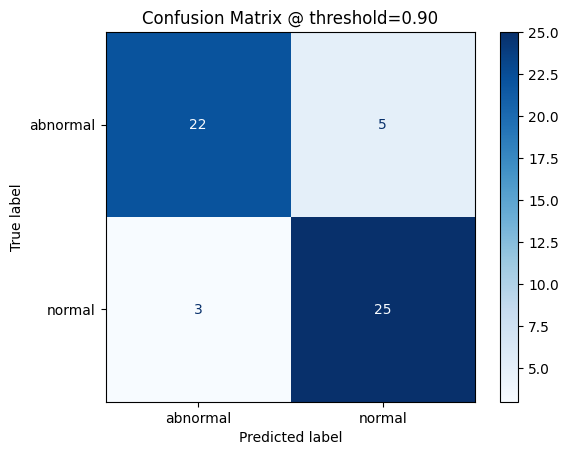

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

# abnormal = positive class
df['y_true'] = df['truth'].apply(lambda x: 1 if x=='abnormal' else 0)
y_true = df['y_true'].values
y_scores = df['confidence'].values

# Precision-Recall + AP
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
ap = average_precision_score(y_true, y_scores)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"AP (mAP): {ap:.4f}")

# PR curve 시각화
plt.figure(figsize=(6,6))
plt.plot(recall, precision, marker='.', label=f'AP={ap:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# 최적 threshold 선택 (F1 최대)
f1_scores = 2*precision*recall/(precision+recall+1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (F1 max): {best_threshold:.2f}")

# Confusion matrix
y_pred = (y_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(cm, display_labels=['abnormal', 'normal'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={best_threshold:.2f}')
plt.show()